In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("clean_dataset.csv")
display(df.head(5))

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),order_month,orderd_hour
0,36.0,4.2,2022-02-12,1900-01-01 21:55:00,22:10,Fog,Jam,Good,Snack,motorcycle,3.0,No,Metropolitian,46,2,21
1,21.0,4.7,2022-02-13,1900-01-01 14:55:00,15:05,Stormy,High,Average,Meal,motorcycle,1.0,No,Metropolitian,23,2,14
2,23.0,4.7,2022-03-04,1900-01-01 17:30:00,17:40,Sandstorms,Medium,Average,Drinks,scooter,1.0,No,Metropolitian,21,3,17
3,34.0,4.3,2022-02-13,1900-01-01 09:20:00,09:30,Sandstorms,Low,Poor,Buffet,motorcycle,0.0,No,Metropolitian,20,2,9
4,24.0,4.7,2022-02-14,1900-01-01 19:50:00,20:05,Fog,Jam,Average,Snack,scooter,1.0,No,Metropolitian,41,2,19


In [11]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,Time_taken (min),order_month,orderd_hour
count,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000
mean,29.556952,4.635676,0.749595,26.293161,2.980731,17.396757
std,5.747386,0.312931,0.567630,9.374274,0.546120,4.811293
min,20.000000,2.500000,0.000000,10.000000,2.000000,0.000000
25%,25.000000,4.500000,0.000000,19.000000,3.000000,15.000000
50%,30.000000,4.700000,1.000000,26.000000,3.000000,19.000000
75%,35.000000,4.900000,1.000000,32.000000,3.000000,21.000000
max,39.000000,5.000000,3.000000,54.000000,4.000000,23.000000


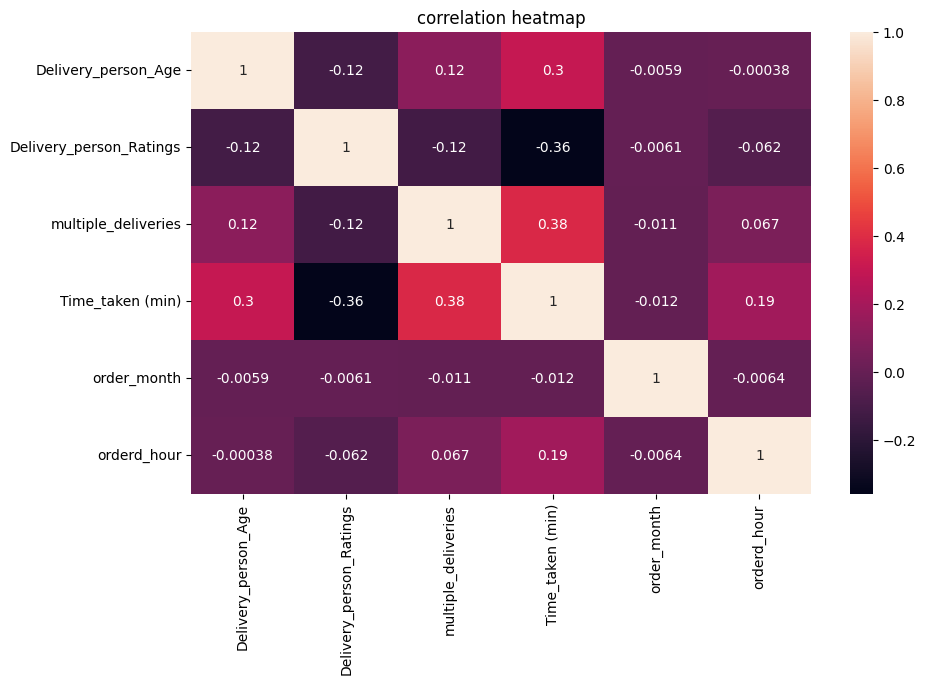

In [12]:
numeric_cols = df.select_dtypes(include=['float64' , 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr() , annot=True  )
plt.title("correlation heatmap")
plt.show()

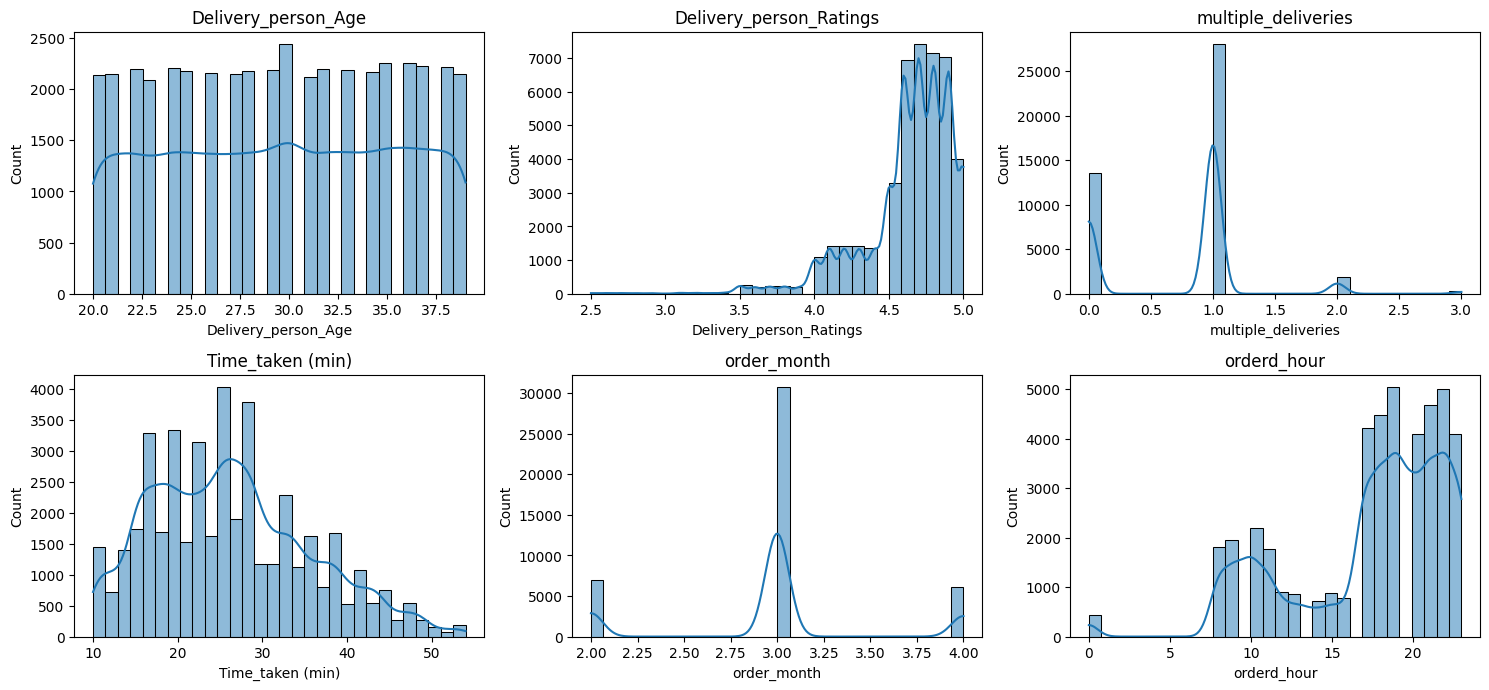

In [15]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
df['Time_Orderd'].dtype

dtype('O')

In [19]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date',
       'Time_Orderd', 'Time_Order_picked', 'Weather_conditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken (min)', 'order_month', 'orderd_hour'],
      dtype='object')

* KPI

In [87]:
avg_time_take = df['Time_taken (min)'].mean()
print(f"avg time taken : {avg_time_take.round(2)}")

avg_orderd_hour = df['orderd_hour'].mean()
print(f"avg orderd hour : {avg_orderd_hour.round(2)}")

avg_delivery_person_rating = df['Delivery_person_Ratings'].mean()
print(f"avg delivery person rate : {avg_delivery_person_rating.round(2)}")


df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M"
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M"
)

avg time taken : 26.29
avg orderd hour : 17.4
avg delivery person rate : 4.64


ValueError: time data "1900-01-01 21:55:00" doesn't match format "%H:%M", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

* age group wise person distribution

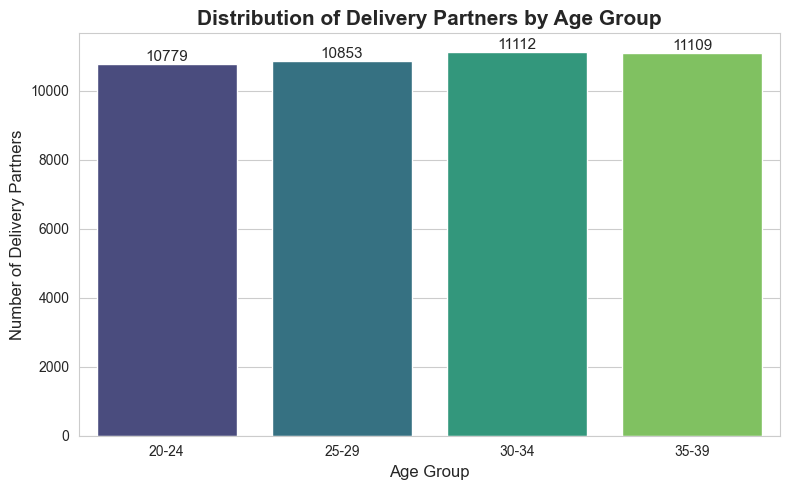

In [29]:
# Create age group column
bins = [19, 24, 29, 34, 39]

labels = [
    "20-24",
    "25-29",
    "30-34",
    "35-39"
]

df["age_group"] = pd.cut(
    df["Delivery_person_Age"],
    bins=bins,
    labels=labels
)
# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="age_group",
    order=["20-24", "25-29", "30-34", "35-39"],
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of Delivery Partners by Age Group", fontsize=15, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Delivery Partners", fontsize=12)

plt.tight_layout()
plt.show()

* base on vehical condition avg delivery person rate

,avg_delivery_person_rate
Vehicle_condition,
Average,4.65
Good,4.65
Poor,4.61


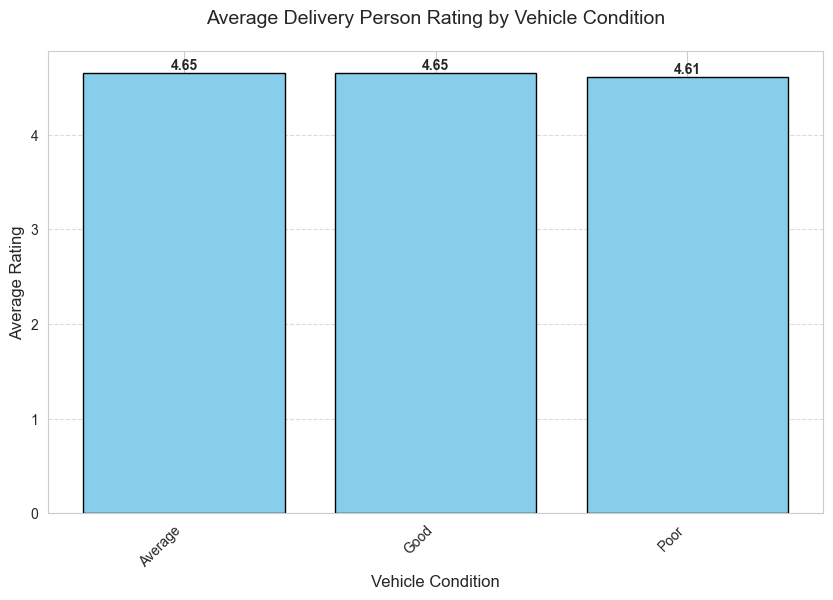

In [ ]:
vehical_condition = df.groupby('Vehicle_condition').agg(
    avg_delivery_person_rate = ('Delivery_person_Ratings' , 'mean')
).round(2)

display(vehical_condition.sort_values(by='avg_delivery_person_rate' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    vehical_condition.index,
    vehical_condition['avg_delivery_person_rate'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average Delivery Person Rating by Vehicle Condition', fontsize=14, pad=20)
plt.xlabel('Vehicle Condition', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

* base on vehical condition avg time taken for deliver order

,avg_time
Vehicle_condition,
Poor,30.05
Good,24.47
Average,24.37


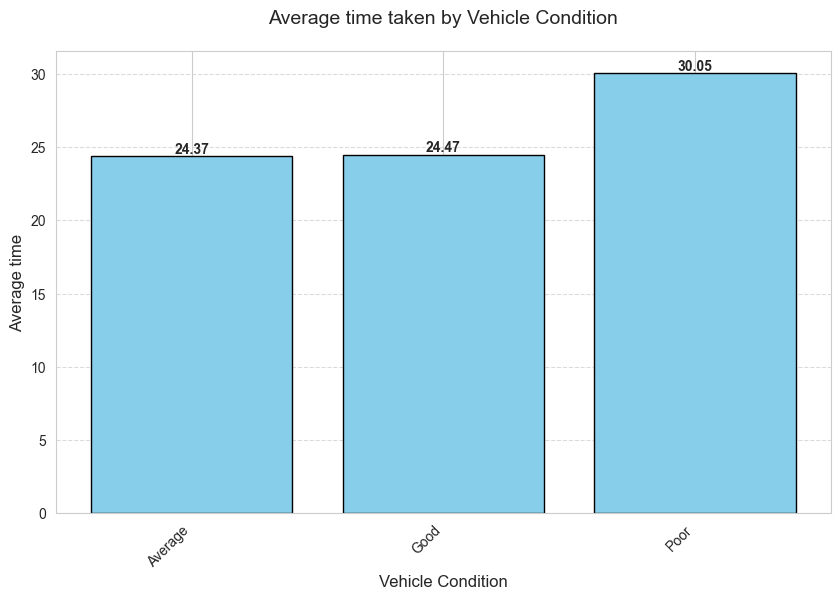

In [38]:
avg_time = df.groupby('Vehicle_condition').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)

display(avg_time.sort_values(by="avg_time", ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    avg_time.index,
    avg_time['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time taken by Vehicle Condition', fontsize=14, pad=20)
plt.xlabel('Vehicle Condition', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

* base on vehical type avg time taken

,avg_time
Type_of_vehicle,
motorcycle,27.60
scooter,24.47
electric_scooter,24.41


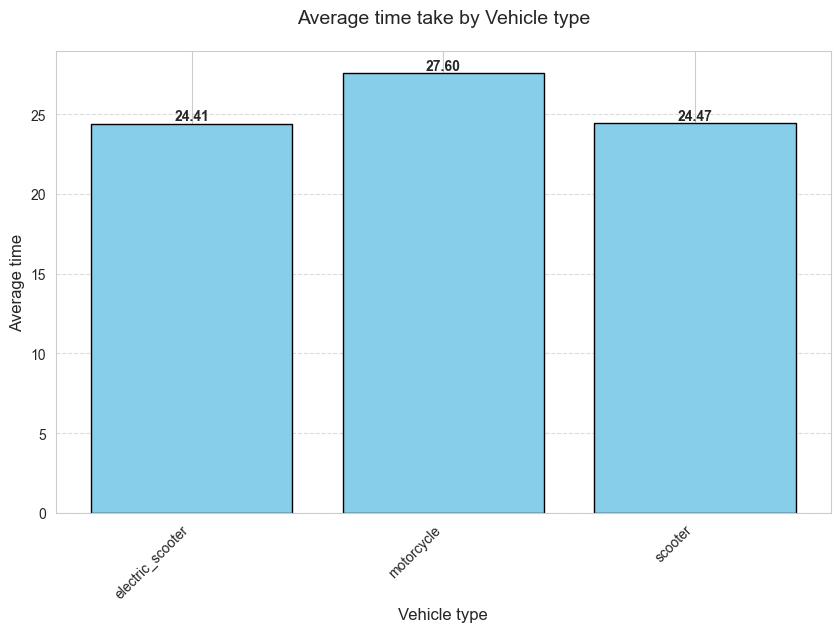

In [40]:
vehical_type = df.groupby('Type_of_vehicle').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)
display(vehical_type.sort_values(by='avg_time' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    vehical_type.index,
    vehical_type['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by Vehicle type', fontsize=14, pad=20)
plt.xlabel('Vehicle type', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

* type of order distribution

Type_of_order
Snack     11088
Meal      11016
Drinks    10896
Buffet    10853
Name: count, dtype: int64

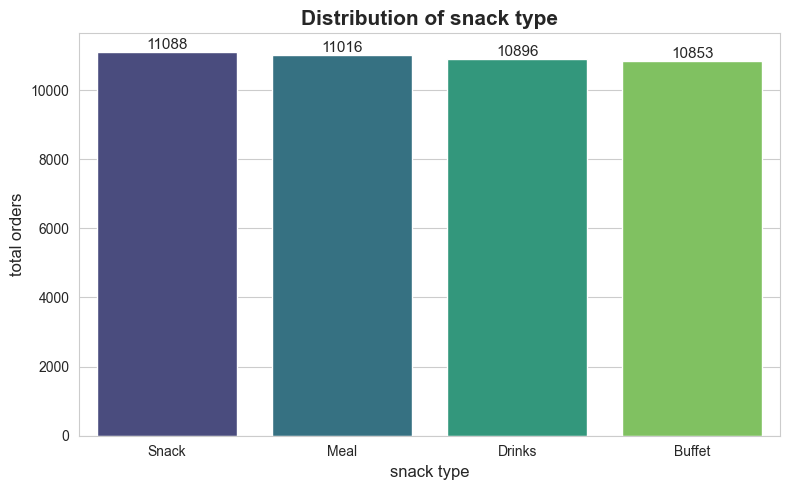

In [42]:
order_type = df['Type_of_order'].value_counts()
display(order_type.sort_values(ascending=False))

# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Type_of_order",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of snack type", fontsize=15, fontweight="bold")
plt.xlabel("snack type", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()

* road trafiic density wise avg time taken

,avg_time
Road_traffic_density,
Jam,31.15
High,27.21
Medium,26.72
Low,21.28


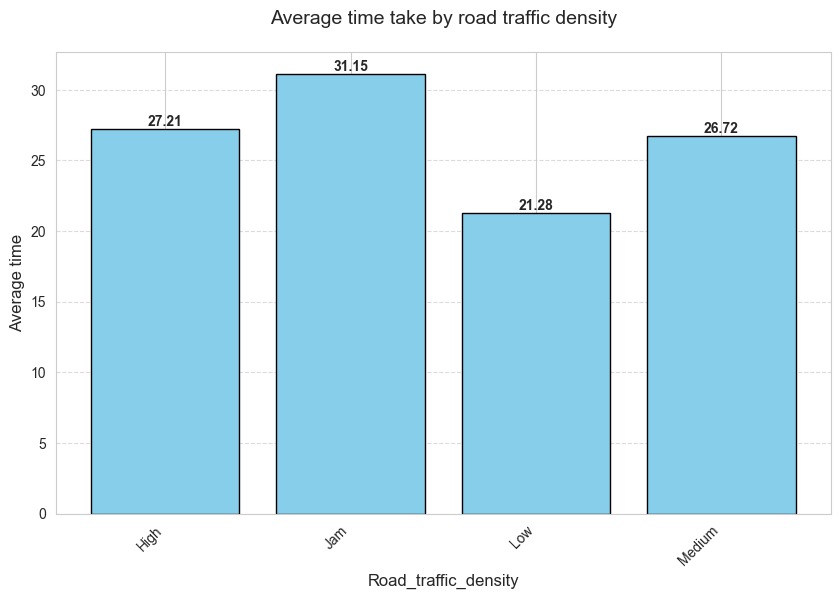

In [51]:
traffic = df.groupby('Road_traffic_density').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)

display(traffic.sort_values(by='avg_time' , ascending=False))
plt.figure(figsize=(10, 6))
bars = plt.bar(
    traffic.index,
    traffic['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by road traffic density', fontsize=14, pad=20)
plt.xlabel('Road_traffic_density', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


* is it possible when driver have multiple deliveries at same time then avg time(for deliver order) taken is higher??

,avg_time
multiple_deliveries,
3.0,47.82
2.0,40.43
1.0,26.72
0.0,22.86


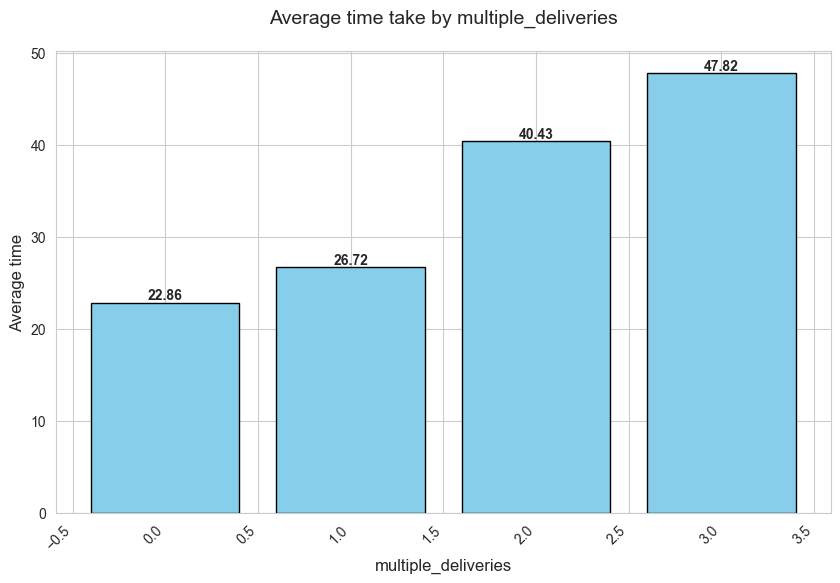

In [57]:
multiple_delivery = df.groupby('multiple_deliveries').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)
display(multiple_delivery.sort_values(by='avg_time',ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    multiple_delivery.index,
    multiple_delivery['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by multiple_deliveries', fontsize=14, pad=20)
plt.xlabel('multiple_deliveries', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

* hourly distribution of orders

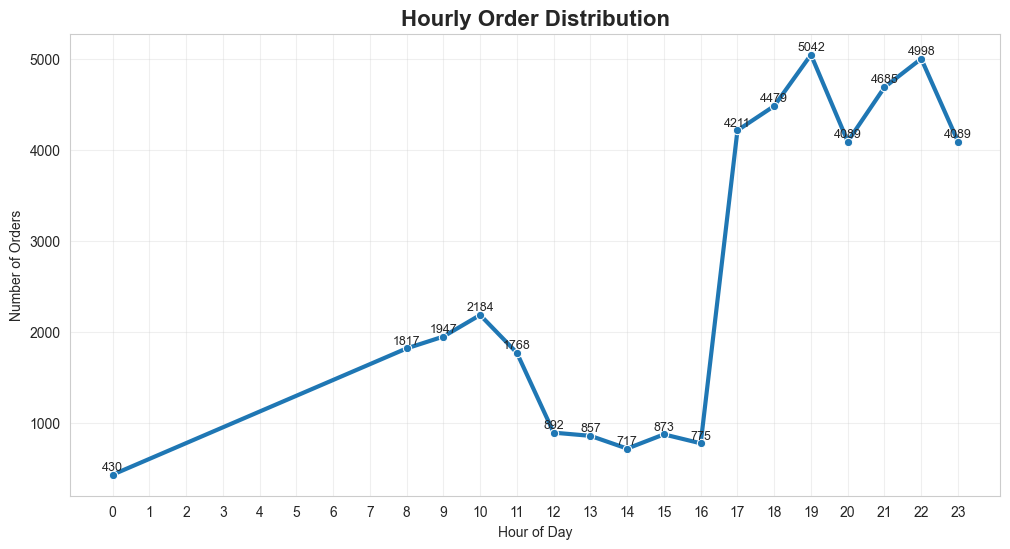

In [72]:
hourly_distribution = df['orderd_hour'].value_counts(ascending=True)
# display(hourly_distribution)
plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_distribution.index,
    y=hourly_distribution.values,
    marker='o',
    linewidth=3
)


# Add value labels
for x, y in zip(hourly_distribution.index, hourly_distribution.values):
    plt.text(x, y + 50, str(y), ha='center', fontsize=9)
plt.title("Hourly Order Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

* monthly distribution

order_month
4     6125
2     6970
3    30758
Name: count, dtype: int64

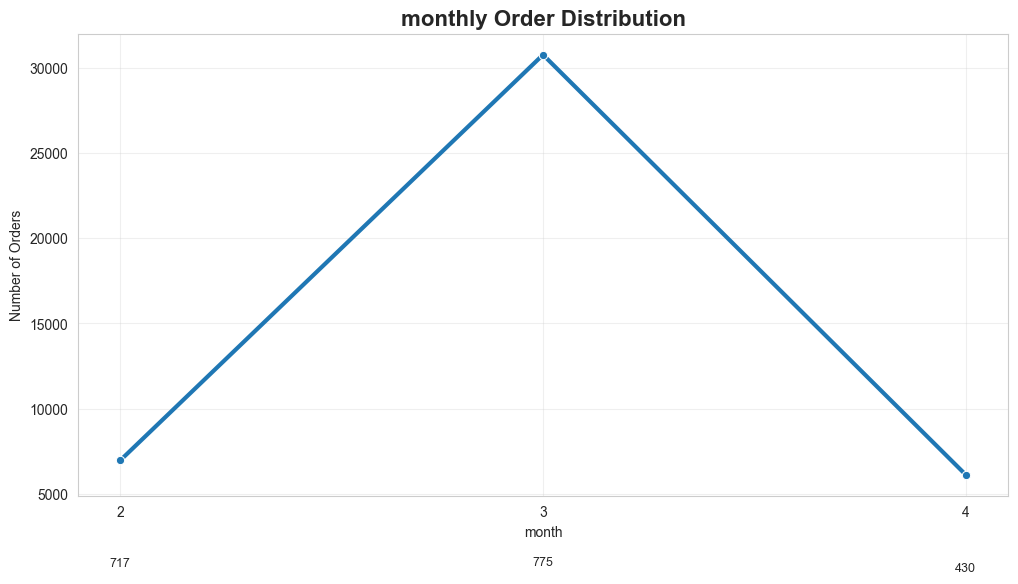

In [80]:
monthly_distribution = df['order_month'].value_counts(ascending=True)
display(monthly_distribution)
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_distribution.index,
    y=monthly_distribution.values,
    marker='o',
    linewidth=3
)


# Add value labels
for x, y in zip(monthly_distribution.index, hourly_distribution.values):
    plt.text(x, y + 50, str(y), ha='center', fontsize=9)
plt.title("monthly Order Distribution", fontsize=16, fontweight="bold")
plt.xlabel("month")
plt.ylabel("Number of Orders")
plt.xticks(monthly_distribution.index)
plt.grid(alpha=0.3)

plt.show()

* city wise zomato used distribution

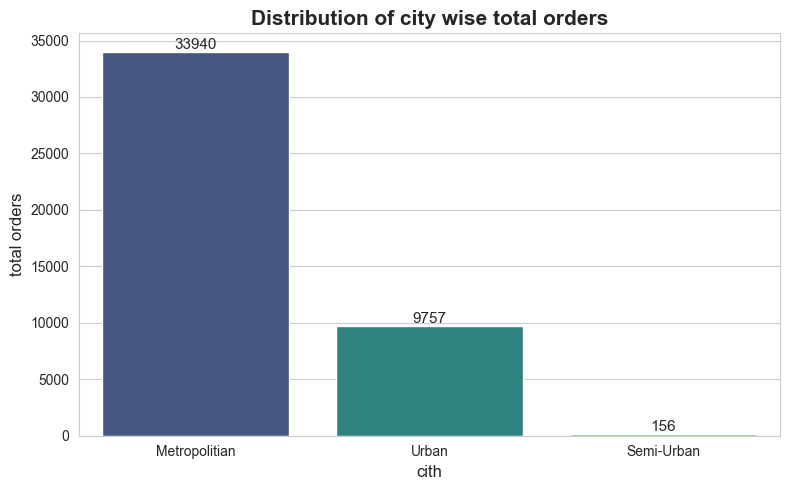

In [84]:
city_orders = (
    df.groupby("City")
      .size()
      .reset_index(name="Total_Orders")
)

# display(city_orders.sort_values(by='Total_Orders' , ascending=False))
# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="City",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of city wise total orders", fontsize=15, fontweight="bold")
plt.xlabel("cith", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()


object
object
